Start with the Rabbits and Foxes KMC implementation from last notebook

In [1]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt
import random
random.seed(1) # so results don't change every time I execute

First, everything is as before, but we've split it into a few functions.

In [15]:
def get_rates(rabbits, foxes):
    """
    Return the rates (expected events per day) as a tuple:
    (rabbit_birth, rabbit_death, fox_birth, fox_death)
    """
    k1 = 0.015
    k2 = 0.00004
    k3 = 0.0004
    k4 = 0.04
    rabbit_birth = k1 * rabbits 
    rabbit_death = k2 * rabbits * foxes
    fox_birth = k3 * rabbits * foxes 
    fox_death = k4 * foxes
    return (rabbit_birth, rabbit_death, fox_birth, fox_death)

def one_run():
    """
    This runs a single Kinetic Monte Carlo simulation
    """
    end_time = 600
    time = 0
    rabbit = 400
    fox = 200
    # we don't know how long these will be so start as lists and convert to arrays later
    times = []
    rabbits = []
    foxes = []
    foxes_died = False
    everything_died = False

    while time < end_time:
        times.append(time)
        rabbits.append(rabbit)
        foxes.append(fox)
        (rabbit_birth, rabbit_death, fox_birth, fox_death) = rates = get_rates(rabbit, fox)
        sum_rates = sum(rates)
        if sum_rates == 0:
            # print("everything dead at t=",time)
            everything_died = True
            times.append(end_time)
            rabbits.append(rabbit)
            foxes.append(fox)
            break
        wait_time = random.expovariate( sum_rates )
        time += wait_time
        choice = random.uniform(0, sum_rates)
        # Imagine we threw a dart at a number line with span (0, sum_rates) and it hit at "choice"
        # Foxes change more often than rabbits, so we'll be faster if we check them first!
        choice -= fox_birth
        if choice < 0:
            fox += 1 # fox born
            continue
        choice -= fox_death
        if choice < 0:
            fox -= 1 # fox died
            if fox == 0:
                #print("Foxes all died at t=",time)
                foxes_died = True
            continue
        if choice < rabbit_birth:
            rabbit += 1 # rabbit born
            continue
        rabbit -= 1 # rabbit died
    
    times = np.array(times)
    rabbits = np.array(rabbits)
    foxes = np.array(foxes)
    
    return times, rabbits, foxes, foxes_died, everything_died


def full_analysis(runs=1000, function=one_run):
    """
    This does the full analysis, running `runs` KMC simulations,
    finding the second peak in each, recording cumulative statistics, etc.
    """
    
    dead_foxes = 0
    dead_everything = 0

    second_peak_times = []
    second_peak_foxes = []

    mean_times = np.zeros(runs)
    mean_foxes = np.zeros(runs)
    upper_quartile_times = np.zeros(runs)
    lower_quartile_times = np.zeros(runs)
    upper_quartile_foxes = np.zeros(runs)
    lower_quartile_foxes = np.zeros(runs)

    for run in range(runs):
        times, rabbits, foxes, foxes_died, everything_died = function()
        if foxes_died:
            dead_foxes += 1
        if everything_died:
            dead_everything += 1

        index_of_second_peak = np.argmax(foxes*(times>200)*(foxes>100))
        if index_of_second_peak:
            second_peak_times.append(times[index_of_second_peak])
            second_peak_foxes.append(foxes[index_of_second_peak])

        if len(second_peak_times)>0:
            mean_times[run] = np.mean(second_peak_times)
            mean_foxes[run] = np.mean(second_peak_foxes)
            upper_quartile_times[run] = np.percentile(second_peak_times,75)
            lower_quartile_times[run] = np.percentile(second_peak_times,25)
            upper_quartile_foxes[run] = np.percentile(second_peak_foxes,75)
            lower_quartile_foxes[run] = np.percentile(second_peak_foxes,25)

        # We don't want to plot too many lines, but would be fun to see a few
        if run < 50:
            plt.plot(times, rabbits, 'b')
            plt.plot(times, foxes, 'g')
    plt.legend(['rabbits','foxes'],loc="best") # put the legend at the best location to avoid overlapping things
    plt.ylim(0,3000)
    plt.show()

    print("Everything died {} times out of {} or {:.1f}%".format(dead_everything, runs, 100*dead_everything/runs))
    print("Foxes died {} times out of {} or {:.1f}%".format(dead_foxes, runs, 100*dead_foxes/runs))

    plt.semilogx(mean_times,'-r')
    plt.semilogx(upper_quartile_times,':r')
    plt.semilogx(lower_quartile_times,':r')
    plt.ylabel('Second peak time (days)')
    plt.xlim(10)
    plt.show()
    print("Second peak (days) is {:.1f} with IQR [{:.1f}-{:.1f}] ".format(mean_times[-1], lower_quartile_times[-1], upper_quartile_times[-1]))

    plt.semilogx(mean_foxes,'-k')
    plt.semilogx(upper_quartile_foxes,':k')
    plt.semilogx(lower_quartile_foxes,':k')
    plt.ylabel('Second peak foxes')
    plt.xlim(10)
    plt.show()
    print("Second peak (foxes) is {:.1f} with IQR [{:.1f}-{:.1f}] ".format(mean_foxes[-1], lower_quartile_foxes[-1], upper_quartile_foxes[-1]))

    from matplotlib.colors import LogNorm
    plt.hist2d(second_peak_times, second_peak_foxes, bins=40, norm=LogNorm())
    plt.xlim(0,600)
    plt.ylim(0)
    plt.colorbar()
    plt.axvline(200,linestyle=':')
    plt.axvline(mean_times[-1],color='r')
    plt.axhline(100,linestyle=':')
    plt.axhline(mean_foxes[-1],color='k')
    plt.show()

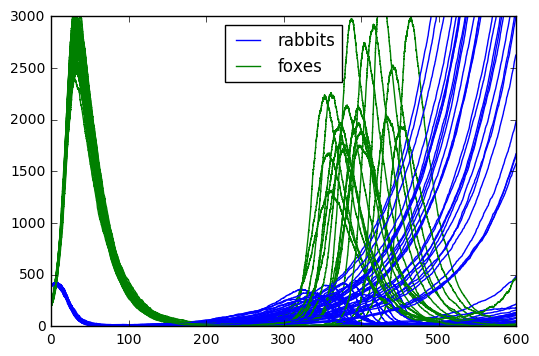

Everything died 219 times out of 10000 or 2.2%
Foxes died 7047 times out of 10000 or 70.5%


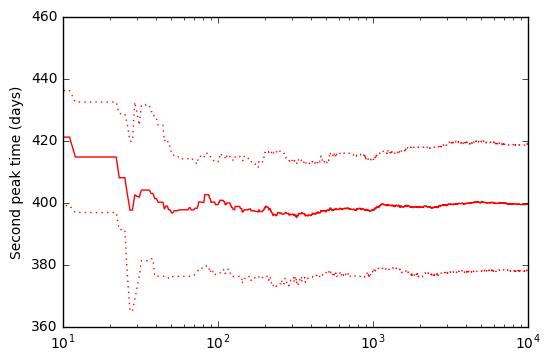

Second peak (days) is 399.6 with IQR [378.1-418.9] 


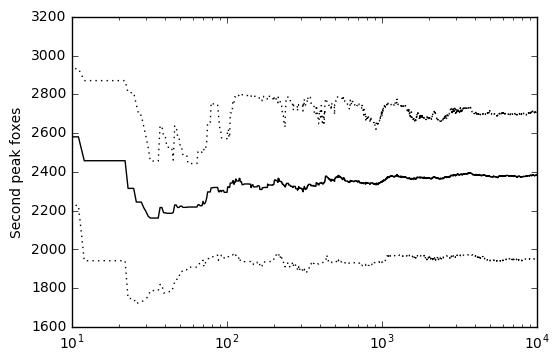

Second peak (foxes) is 2385.3 with IQR [1954.0-2719.0] 
1 loop, best of 1: 8min 39s per loop


In [3]:
%%timeit -n1 -r1
full_analysis(runs=10000)

In [4]:
%timeit one_run()

100 loops, best of 3: 46.5 ms per loop


# Cython
In an anaconda prompt (the terminal on a mac) type:

    conda install cython

In [5]:
%load_ext Cython

First, just stick `%%cython` at the top of the cell in which we define functions, and see what difference it makes when we execute them.

In [6]:
%%cython
import random
import numpy as np
def get_rates(rabbits, foxes):
    """
    Return the rates (expected events per day) as a tuple:
    (rabbit_birth, rabbit_death, fox_birth, fox_death)
    """
    k1 = 0.015
    k2 = 0.00004
    k3 = 0.0004
    k4 = 0.04
    rabbit_birth = k1 * rabbits 
    rabbit_death = k2 * rabbits * foxes
    fox_birth = k3 * rabbits * foxes 
    fox_death = k4 * foxes
    return (rabbit_birth, rabbit_death, fox_birth, fox_death)

def one_run():
    """
    This runs a single Kinetic Monte Carlo simulation
    """
    end_time = 600
    time = 0
    rabbit = 400
    fox = 200
    # we don't know how long these will be so start as lists and convert to arrays later
    times = []
    rabbits = []
    foxes = []
    foxes_died = False
    everything_died = False

    while time < end_time:
        times.append(time)
        rabbits.append(rabbit)
        foxes.append(fox)
        (rabbit_birth, rabbit_death, fox_birth, fox_death) = rates = get_rates(rabbit, fox)
        sum_rates = sum(rates)
        if sum_rates == 0:
            # print("everything dead at t=",time)
            everything_died = True
            times.append(end_time)
            rabbits.append(rabbit)
            foxes.append(fox)
            break
        wait_time = random.expovariate( sum_rates )
        time += wait_time
        choice = random.uniform(0, sum_rates)
        # Imagine we threw a dart at a number line with span (0, sum_rates) and it hit at "choice"
        # Foxes change more often than rabbits, so we'll be faster if we check them first!
        choice -= fox_birth
        if choice < 0:
            fox += 1 # fox born
            continue
        choice -= fox_death
        if choice < 0:
            fox -= 1 # fox died
            if fox == 0:
                #print("Foxes all died at t=",time)
                foxes_died = True
            continue
        if choice < rabbit_birth:
            rabbit += 1 # rabbit born
            continue
        rabbit -= 1 # rabbit died
    
    times = np.array(times)
    rabbits = np.array(rabbits)
    foxes = np.array(foxes)
    
    return times, rabbits, foxes, foxes_died, everything_died

In [7]:
%timeit one_run()

10 loops, best of 3: 38.5 ms per loop


Just looking at random number generation, let's compare some alternatives

In [8]:
%timeit random.random()

The slowest run took 20.61 times longer than the fastest. This could mean that an intermediate result is being cached.
10000000 loops, best of 3: 82.7 ns per loop


In [9]:
%%cython
from libc.stdlib cimport rand, RAND_MAX
cpdef double my_random():
    "My random number"
    return 1.0*rand()/RAND_MAX

In [10]:
%timeit my_random()

The slowest run took 34.68 times longer than the fastest. This could mean that an intermediate result is being cached.
10000000 loops, best of 3: 48.8 ns per loop


The customized random number is twice as fast.

Here's an optimized cythonized version of our KMC algorithm

In [11]:
%%cython --annotate
import random
import numpy as np
cimport numpy as np
from libc.stdlib cimport rand, RAND_MAX
from libc.math cimport log

import cython
@cython.cdivision(True)
cpdef tuple one_run_cython():
    """
    This runs a single Kinetic Monte Carlo simulation
    """
    cdef double k1, k2, k3, k4, rabbit_birth, rabbit_death, fox_birth, fox_death
    cdef double end_time, time, sum_rates, 
    cdef double wait_time, choice
    cdef int rabbit, fox
    cdef list times, rabbits, foxes
    cdef bint foxes_died, everything_died
    cdef np.ndarray[np.float64_t, ndim=1] times_array, 
    cdef np.ndarray[np.int_t, ndim=1] rabbits_array, foxes_array

    end_time = 600
    time = 0
    rabbit = 400
    fox = 200
    # we don't know how long these will be so start as lists and convert to arrays later
    times = []
    rabbits = []
    foxes = []
    foxes_died = False
    everything_died = False
    
    k1 = 0.015
    k2 = 0.00004
    k3 = 0.0004
    k4 = 0.04

    while time < end_time:
        times.append(time)
        rabbits.append(rabbit)
        foxes.append(fox)

        rabbit_birth = k1 * rabbit 
        rabbit_death = k2 * rabbit * fox
        fox_birth = k3 * rabbit * fox
        fox_death = k4 * fox
    
    
        sum_rates = rabbit_birth + rabbit_death + fox_birth + fox_death
        if sum_rates == 0:
            # print("everything dead at t=",time)
            everything_died = True
            times.append(end_time)
            rabbits.append(rabbit)
            foxes.append(fox)
            break
        #wait_time = random.expovariate( sum_rates )
        wait_time = -log((RAND_MAX-rand())/1.0/RAND_MAX) / sum_rates 
        time += wait_time
        choice = sum_rates * rand() / RAND_MAX
        # Imagine we threw a dart at a number line with span (0, sum_rates) and it hit at "choice"
        # Foxes change more often than rabbits, so we'll be faster if we check them first!
        choice -= fox_birth
        if choice < 0:
            fox += 1 # fox born
            continue
        choice -= fox_death
        if choice < 0:
            fox -= 1 # fox died
            if fox == 0:
                #print("Foxes all died at t=",time)
                foxes_died = True
            continue
        if choice < rabbit_birth:
            rabbit += 1 # rabbit born
            continue
        rabbit -= 1 # rabbit died
    
    times_array = np.array(times)
    rabbits_array = np.array(rabbits)
    foxes_array = np.array(foxes)
    
    return times_array, rabbits_array, foxes_array, foxes_died, everything_died

In [12]:
one_run_cython()

(array([  0.00000000e+00,   8.04142722e-03,   1.19782009e-02, ...,
          5.95297093e+02,   5.95507657e+02,   5.97348132e+02]),
 array([400, 400, 400, ...,  24,  25,  25]),
 array([200, 199, 198, ...,   3,   3,   4]),
 False,
 False)

In [13]:
%timeit one_run_cython()

10 loops, best of 3: 16.7 ms per loop


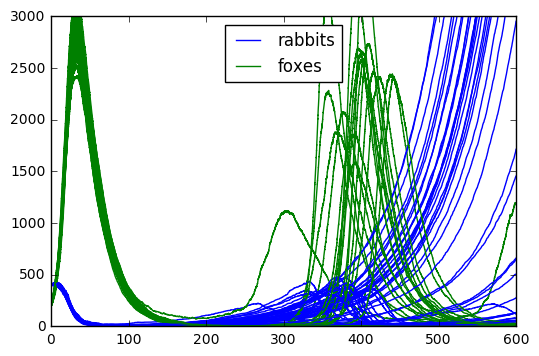

Everything died 165 times out of 10000 or 1.6%
Foxes died 6987 times out of 10000 or 69.9%


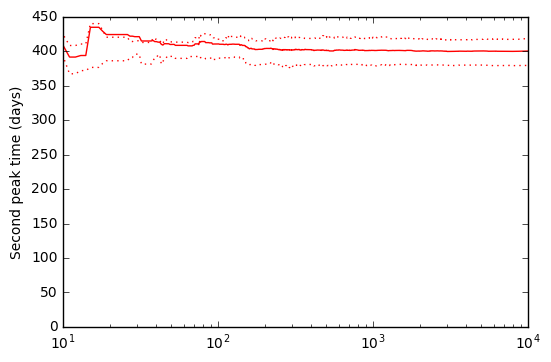

Second peak (days) is 400.4 with IQR [379.5-418.4] 


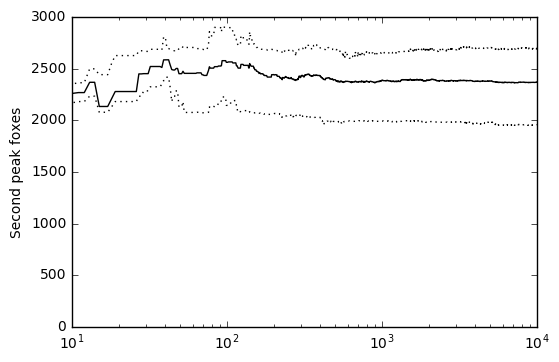

Second peak (foxes) is 2369.5 with IQR [1957.0-2696.0] 
1 loop, best of 1: 1min 38s per loop


In [14]:
%%timeit -n1 -r1
full_analysis(runs=10000, function=one_run_cython)

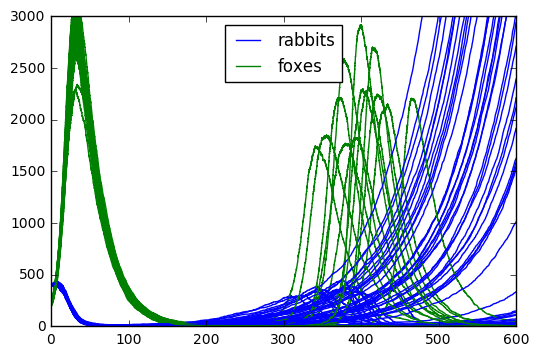

Everything died 1763 times out of 100000 or 1.8%
Foxes died 69879 times out of 100000 or 69.9%


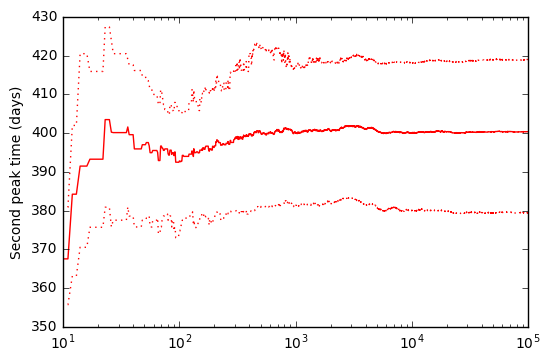

Second peak (days) is 400.4 with IQR [379.4-419.1] 


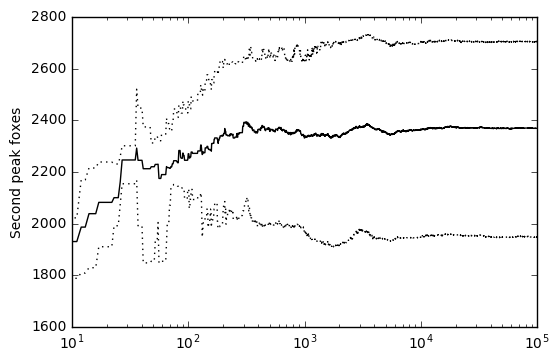

Second peak (foxes) is 2368.5 with IQR [1947.0-2705.0] 


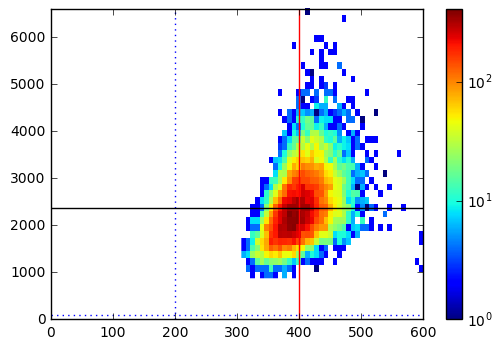

1 loop, best of 1: 30min 55s per loop


In [16]:
%%timeit -n1 -r1
full_analysis(runs=100000, function=one_run_cython)